In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Reading Data
df = pd.DataFrame(pd.read_csv("Data/CO2 Emissions.csv"))
df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232


In [3]:
df = df[['Engine Size(L)' , 'Cylinders' , 'Fuel Type' , 'Fuel Consumption City (L/100 km)' ,
         'Fuel Consumption Hwy (L/100 km)' , 'Fuel Consumption Comb (L/100 km)' , 'Fuel Consumption Comb (mpg)',
         'CO2 Emissions(g/km)']]
df.head()

,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,2.0,4,Z,9.9,6.7,8.5,33,196
1,2.4,4,Z,11.2,7.7,9.6,29,221
2,1.5,4,Z,6.0,5.8,5.9,48,136
3,3.5,6,Z,12.7,9.1,11.1,25,255
4,3.5,6,Z,12.1,8.7,10.6,27,244


<font size="5" >**Data Analysis**</font>

In [4]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Engine Size(L)                    7385 non-null   float64
 1   Cylinders                         7385 non-null   int64  
 2   Fuel Type                         7385 non-null   object 
 3   Fuel Consumption City (L/100 km)  7385 non-null   float64
 4   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 5   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 6   Fuel Consumption Comb (mpg)       7385 non-null   int64  
 7   CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 461.7+ KB


In [6]:
df = df.dropna()
df

,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,2.0,4,Z,9.9,6.7,8.5,33,196
1,2.4,4,Z,11.2,7.7,9.6,29,221
2,1.5,4,Z,6.0,5.8,5.9,48,136
3,3.5,6,Z,12.7,9.1,11.1,25,255
4,3.5,6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...
7380,2.0,4,Z,10.7,7.7,9.4,30,219
7381,2.0,4,Z,11.2,8.3,9.9,29,232
7382,2.0,4,Z,11.7,8.6,10.3,27,240
7383,2.0,4,Z,11.2,8.3,9.9,29,232


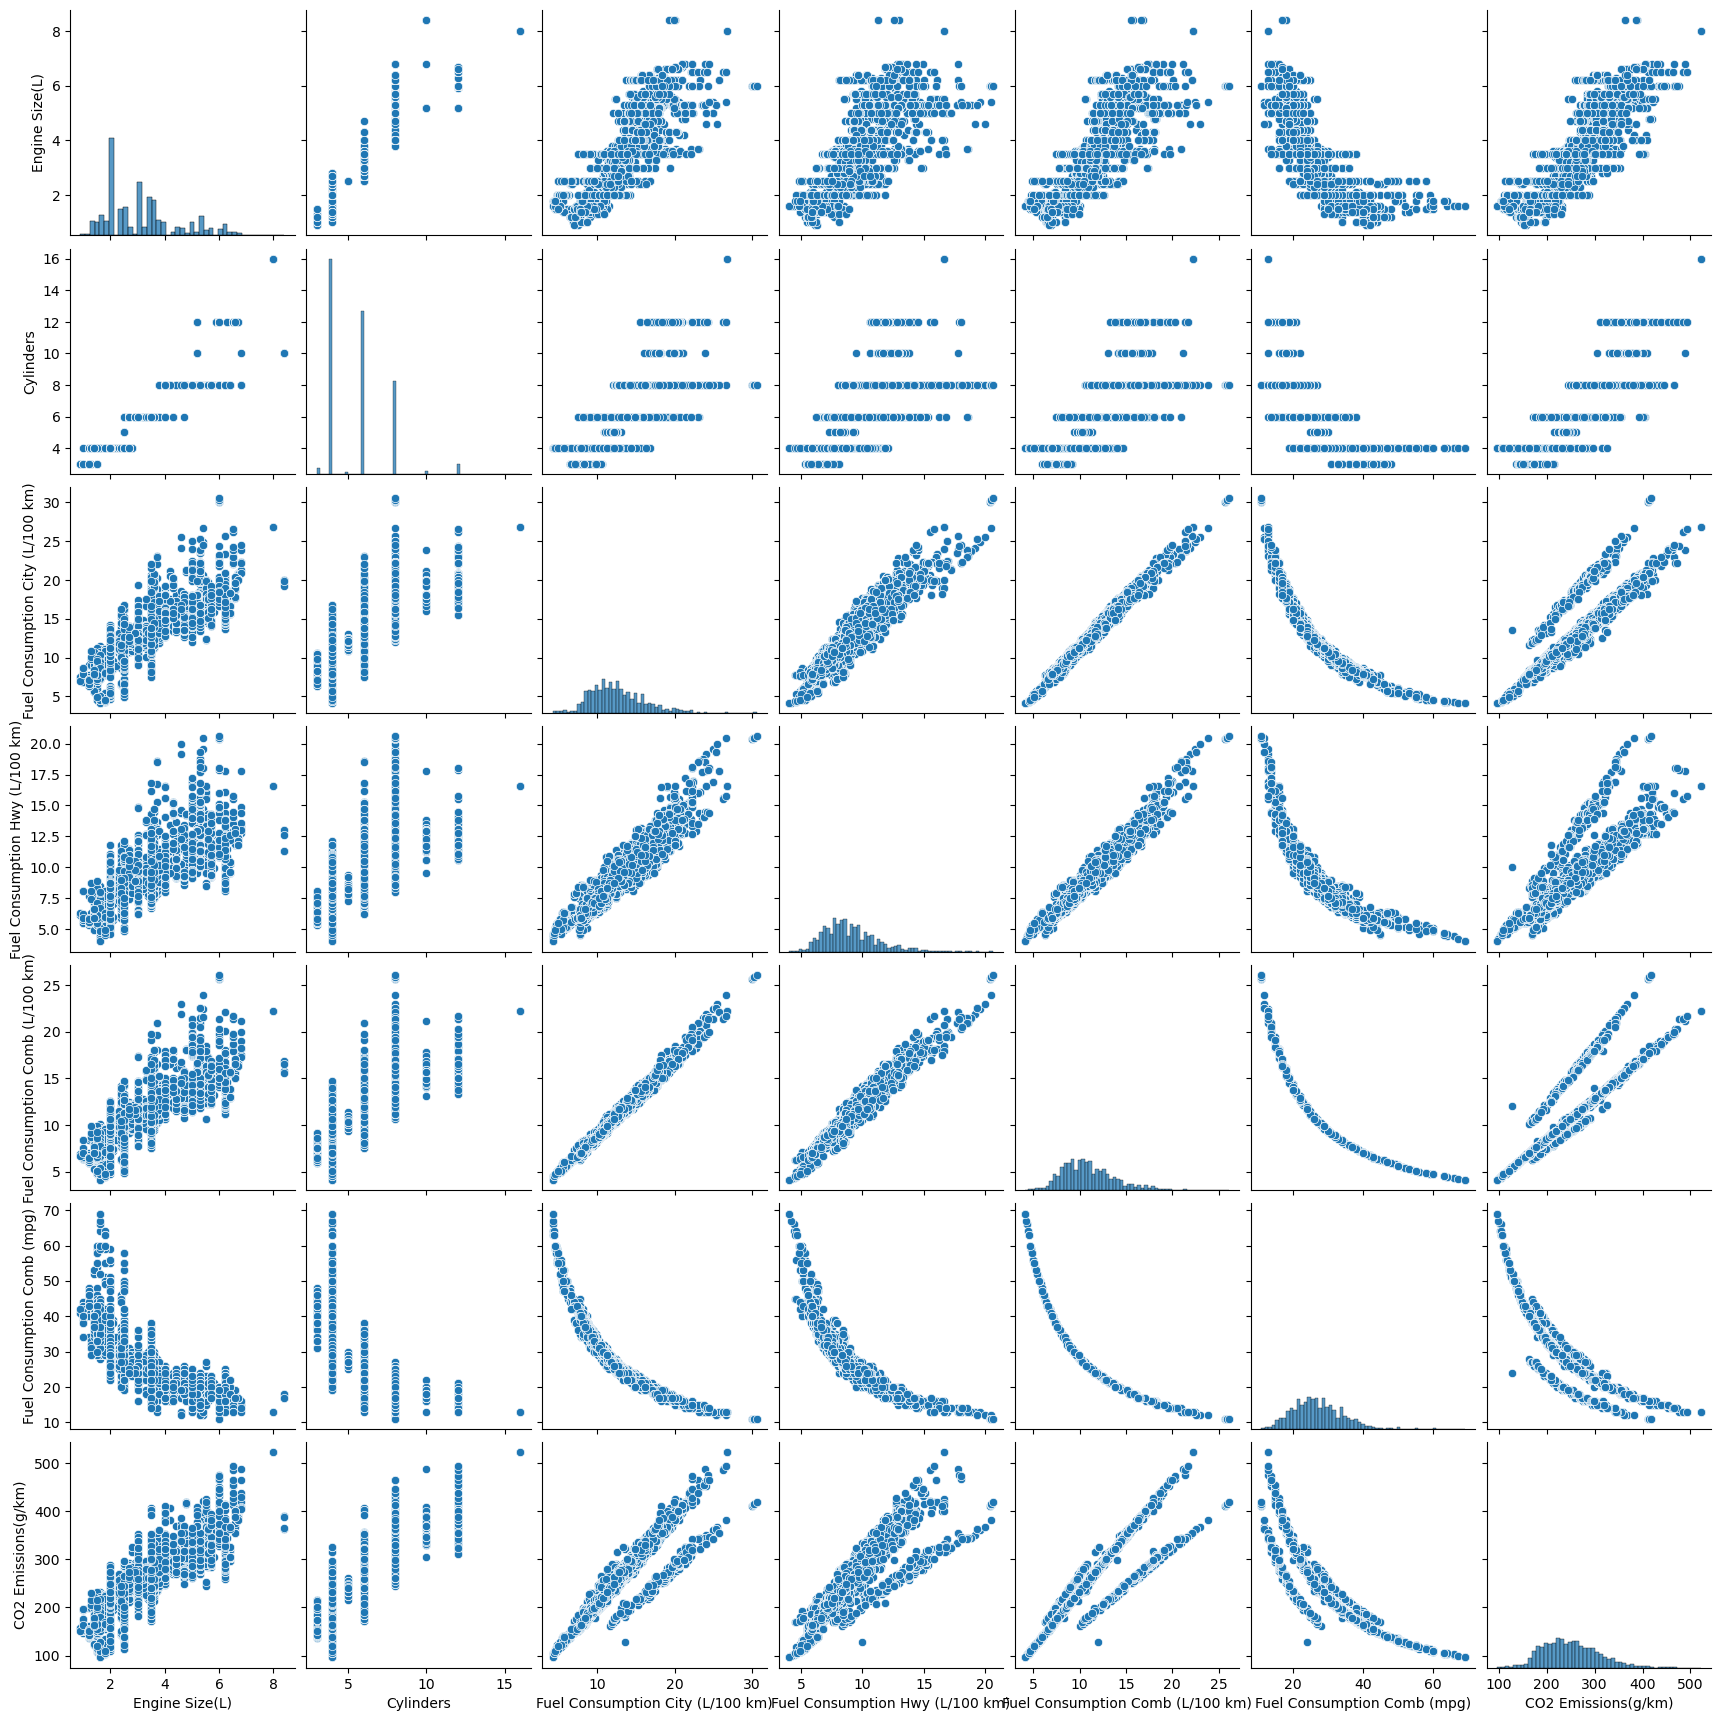

In [7]:
sns.pairplot(df)

<font size="5">**Dimension reduction**</font>

In [8]:
Ftype = pd.get_dummies(df['Fuel Type'], drop_first = True)
Ftype

,E,N,X,Z
0,0,0,0,1
1,0,0,0,1
2,0,0,0,1
3,0,0,0,1
4,0,0,0,1
...,...,...,...,...
7380,0,0,0,1
7381,0,0,0,1
7382,0,0,0,1
7383,0,0,0,1


In [9]:
df = pd.concat([df, Ftype], axis = 1)
df

,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),E,N,X,Z
0,2.0,4,Z,9.9,6.7,8.5,33,196,0,0,0,1
1,2.4,4,Z,11.2,7.7,9.6,29,221,0,0,0,1
2,1.5,4,Z,6.0,5.8,5.9,48,136,0,0,0,1
3,3.5,6,Z,12.7,9.1,11.1,25,255,0,0,0,1
4,3.5,6,Z,12.1,8.7,10.6,27,244,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,2.0,4,Z,10.7,7.7,9.4,30,219,0,0,0,1
7381,2.0,4,Z,11.2,8.3,9.9,29,232,0,0,0,1
7382,2.0,4,Z,11.7,8.6,10.3,27,240,0,0,0,1
7383,2.0,4,Z,11.2,8.3,9.9,29,232,0,0,0,1


In [10]:
df.drop(['Fuel Type'], axis = 1, inplace = True)
df.head(10)

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),E,N,X,Z
0,2.0,4,9.9,6.7,8.5,33,196,0,0,0,1
1,2.4,4,11.2,7.7,9.6,29,221,0,0,0,1
2,1.5,4,6.0,5.8,5.9,48,136,0,0,0,1
3,3.5,6,12.7,9.1,11.1,25,255,0,0,0,1
4,3.5,6,12.1,8.7,10.6,27,244,0,0,0,1
5,3.5,6,11.9,7.7,10.0,28,230,0,0,0,1
6,3.5,6,11.8,8.1,10.1,28,232,0,0,0,1
7,3.7,6,12.8,9.0,11.1,25,255,0,0,0,1
8,3.7,6,13.4,9.5,11.6,24,267,0,0,0,1
9,2.4,4,10.6,7.5,9.2,31,212,0,0,0,1


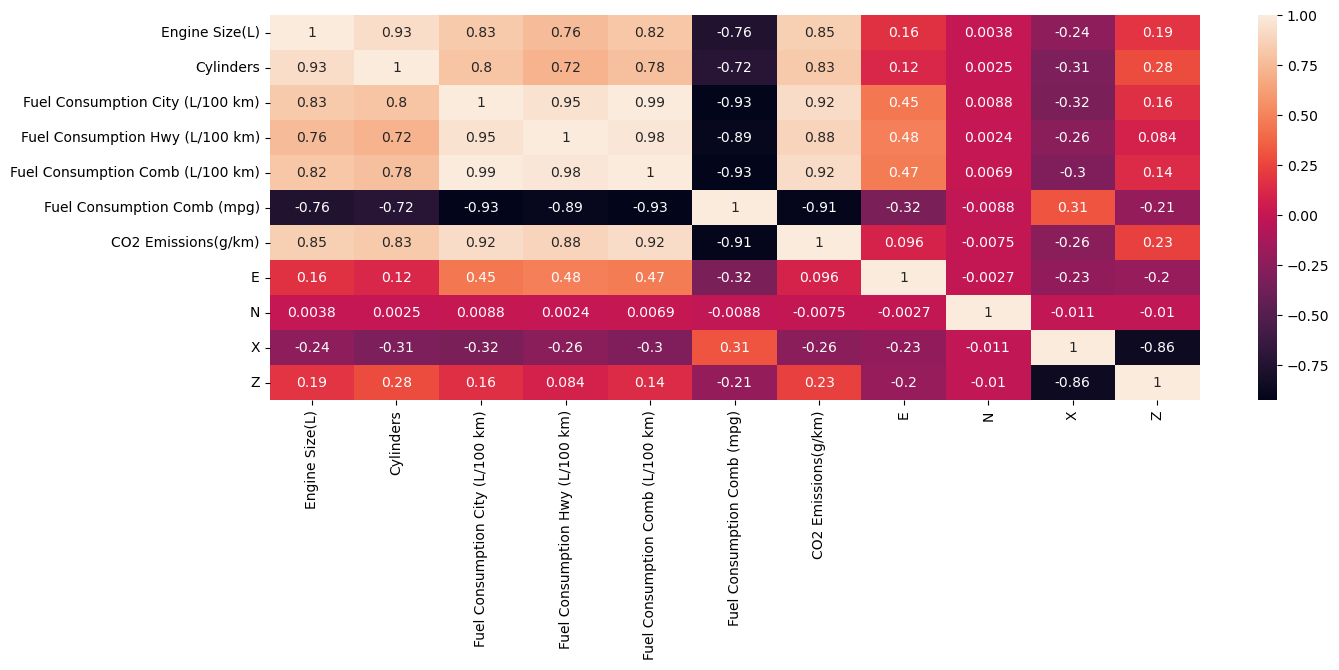

In [11]:
import seaborn as sns
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(),annot=True)
plt.show()

<font size="5">**Training & Testing Data Split**</font>

In [12]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, train_size = 0.8, test_size = 0.2, random_state = 2)

In [13]:
df_train.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),E,N,X,Z
7220,3.7,6,12.6,9.3,11.1,25,261,0,0,0,1
7305,2.5,4,8.8,6.7,7.9,36,185,0,0,1,0
5799,3.5,6,20.4,13.1,17.1,17,402,0,0,0,1
5343,6.6,12,20.3,13.0,17.0,17,397,0,0,0,1
6883,5.3,8,14.3,10.6,12.7,22,298,0,0,1,0


In [14]:
df_test.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),E,N,X,Z
3773,5.3,8,15.2,10.8,13.2,21,310,0,0,1,0
2805,2.0,4,10.3,7.8,9.2,31,214,0,0,1,0
194,6.2,8,16.7,12.5,14.8,19,340,0,0,0,1
7274,5.7,8,16.2,10.5,13.6,21,320,0,0,1,0
1660,5.0,8,15.6,10.9,13.4,21,308,0,0,0,1


<font size="5">**Linear Regression**</font>

In [16]:
# BiVariant Training Data
X_bivarianttrain = df_train.iloc[: , df_train.columns == 'Fuel Consumption City (L/100 km)']
Y_bivarianttrain = df_train['CO2 Emissions(g/km)']

In [17]:
# Training for Bivariant Data
from sklearn.linear_model import LinearRegression

ln_bi = LinearRegression()

linearmodel_bi = ln_bi.fit(X_bivarianttrain, Y_bivarianttrain)

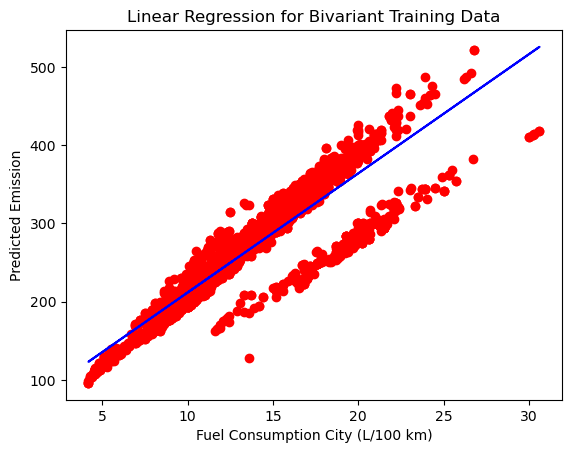

In [18]:
plt.scatter(X_bivarianttrain , Y_bivarianttrain , color = 'red')
plt.plot(X_bivarianttrain , linearmodel_bi.predict(X_bivarianttrain) , color = 'blue')
plt.xlabel('Fuel Consumption City (L/100 km)')
plt.ylabel('Predicted Emission')
plt.title('Linear Regression for Bivariant Training Data')
plt.show()

In [19]:
# BiVariant Test Data
X_bivarianttest = df_test.iloc[: , df_test.columns == 'Fuel Consumption City (L/100 km)']
Y_bivarianttest = df_test['CO2 Emissions(g/km)']

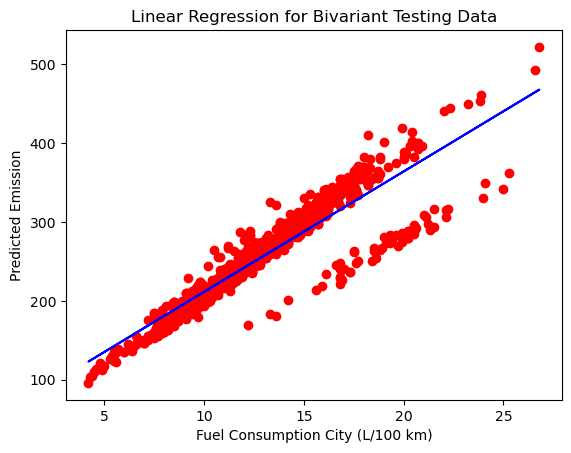

In [20]:
plt.scatter(X_bivarianttest , Y_bivarianttest , color = 'red')
plt.plot(X_bivarianttest , linearmodel_bi.predict(X_bivarianttest) , color = 'blue')
plt.xlabel('Fuel Consumption City (L/100 km)')
plt.ylabel('Predicted Emission')
plt.title('Linear Regression for Bivariant Testing Data')
plt.show()

In [21]:
# Multivariant Training Data
X_train = df_train.iloc[:, df_train.columns != 'CO2 Emissions(g/km)']
Y_train = df_train['CO2 Emissions(g/km)']

In [22]:
# Training for Multivariant Data
from sklearn.linear_model import LinearRegression

ln_multi = LinearRegression()

linearmodel_multi = ln_multi.fit(X_train, Y_train)

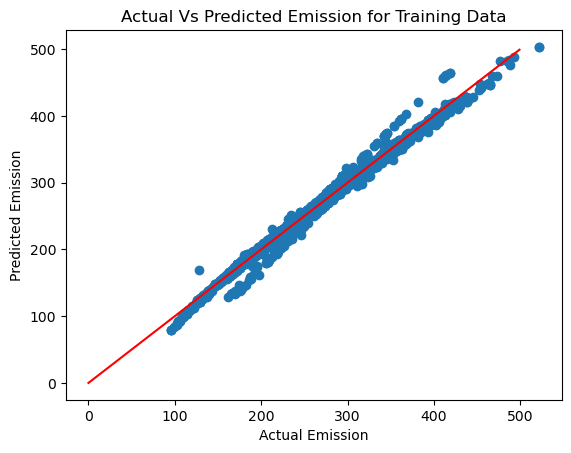

In [23]:
Predicted_Emission = linearmodel_multi.predict(X_train)
Actual_Emission = Y_train

plt.scatter(Actual_Emission,Predicted_Emission)
plt.plot(range(500),range(500) , color = 'red')
plt.xlabel('Actual Emission')
plt.ylabel('Predicted Emission')
plt.title('Actual Vs Predicted Emission for Training Data')
plt.show()

In [24]:
# Multivariant Testing Data

X_test = df_test.iloc[:, df_test.columns != 'CO2 Emissions(g/km)']
Y_test = df_test['CO2 Emissions(g/km)']

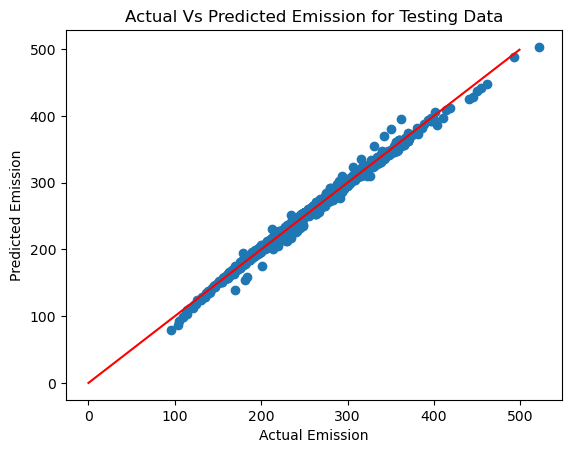

In [25]:
Predicted_Emission = linearmodel_multi.predict(X_test)
Actual_Emission = Y_test

plt.scatter(Actual_Emission,Predicted_Emission)
plt.plot(range(500),range(500) , color = 'red')
plt.xlabel('Actual Emission')
plt.ylabel('Predicted Emission')
plt.title('Actual Vs Predicted Emission for Testing Data')
plt.show()

In [26]:
linear_bi_train_score = linearmodel_bi.score(X_bivarianttrain , Y_bivarianttrain)
linear_bi_test_score = linearmodel_bi.score(X_bivarianttest , Y_bivarianttest)
linear_multi_train_score = linearmodel_multi.score(X_train, Y_train)
linear_multi_test_score = linearmodel_multi.score(X_test , Y_test)

print('\t\t\tLinear Regression ')
print('Score \t\t Training Data \t\t Testing Data')
print('Bivariant \t' , linear_bi_train_score , '\t' , linear_bi_test_score)
print('Multivariant \t' , linear_multi_train_score  , '\t' , linear_multi_test_score)

			Linear Regression 
Score 		 Training Data 		 Testing Data
Bivariant 	 0.8427749648867768 	 0.8570067872140167
Multivariant 	 0.9924741962440671 	 0.994151037968295


<font size="5">**Polynomial Regression**</font>

In [28]:
# BiVariant Training Data
df_train = df_train.sort_values('Fuel Consumption Comb (mpg)')
X_bivarianttrain = df_train.iloc[: , df_train.columns == 'Fuel Consumption Comb (mpg)']
Y_bivarianttrain = df_train['CO2 Emissions(g/km)']

In [29]:
# Training for Bivariant Data
from sklearn.preprocessing import PolynomialFeatures

poly_bi = PolynomialFeatures(degree = 3)
X_poly_bi = poly_bi.fit_transform(X_bivarianttrain)

pol_bi = LinearRegression() 
pol_bi.fit(X_poly_bi, Y_bivarianttrain)

LinearRegression()

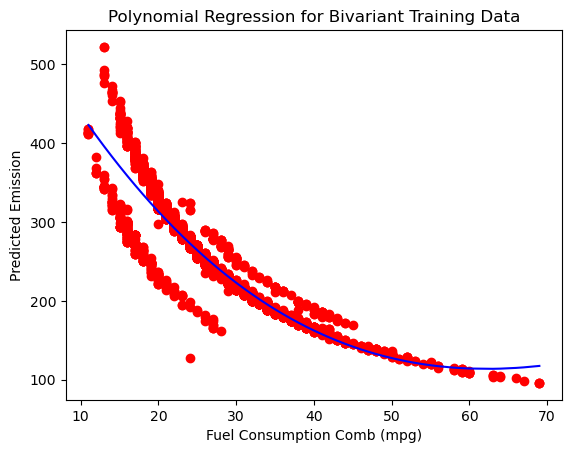

In [30]:
plt.scatter(X_bivarianttrain , Y_bivarianttrain , color = 'red')
plt.plot(X_bivarianttrain , pol_bi.predict(X_poly_bi) , color = 'blue')
plt.xlabel('Fuel Consumption Comb (mpg)')
plt.ylabel('Predicted Emission')
plt.title('Polynomial Regression for Bivariant Training Data')
plt.show()

In [31]:
# BiVariant Test Data
df_test = df_test.sort_values('Fuel Consumption Comb (mpg)')
X_bivarianttest = df_test.iloc[: , df_test.columns == 'Fuel Consumption Comb (mpg)']
Y_bivarianttest = df_test['CO2 Emissions(g/km)']

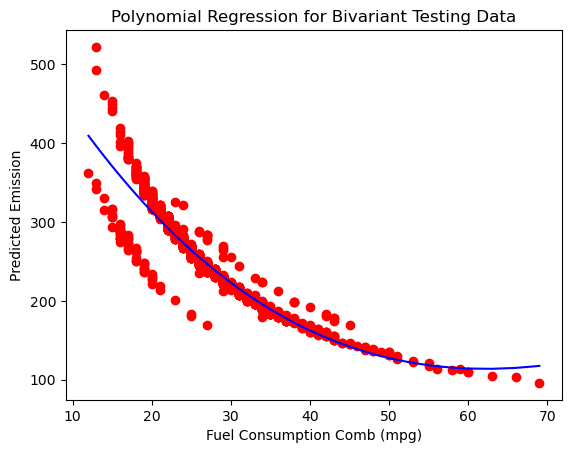

In [32]:
plt.scatter(X_bivarianttest , Y_bivarianttest , color = 'red')
plt.plot(X_bivarianttest , pol_bi.predict(poly_bi.fit_transform(X_bivarianttest)) , color = 'blue')
plt.xlabel('Fuel Consumption Comb (mpg)')
plt.ylabel('Predicted Emission')
plt.title('Polynomial Regression for Bivariant Testing Data')
plt.show()

In [33]:
# Multivariant Training Data
X_train = df_train.iloc[:, df_train.columns != 'CO2 Emissions(g/km)']
Y_train = df_train['CO2 Emissions(g/km)']

In [34]:
# Training for Multivariant Data
from sklearn.linear_model import LinearRegression

poly_multi = PolynomialFeatures(degree = 3)
X_poly_multi = poly_multi.fit_transform(X_train)

pol_multi = LinearRegression() 
pol_multi.fit(X_poly_multi, Y_train)

LinearRegression()

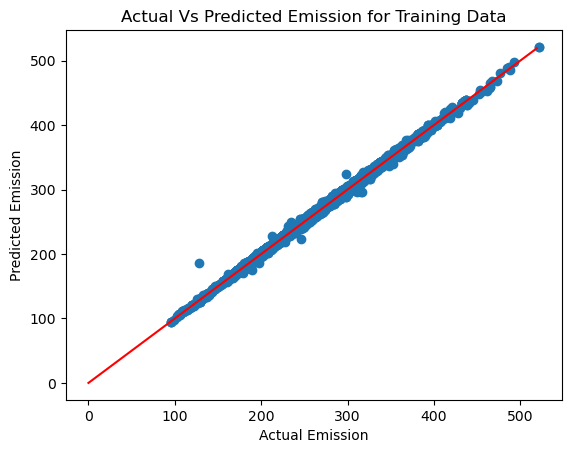

In [35]:
Predicted_Emission = pol_multi.predict(poly_multi.fit_transform(X_train))
Actual_Emission = Y_train

plt.scatter(Actual_Emission,Predicted_Emission)
plt.plot(range(520),range(520) , color = 'red')
plt.xlabel('Actual Emission')
plt.ylabel('Predicted Emission')
plt.title('Actual Vs Predicted Emission for Training Data')
plt.show()

In [36]:
# Multivariant Testing Data

X_test = df_test.iloc[:, df_test.columns != 'CO2 Emissions(g/km)']
Y_test = df_test['CO2 Emissions(g/km)']

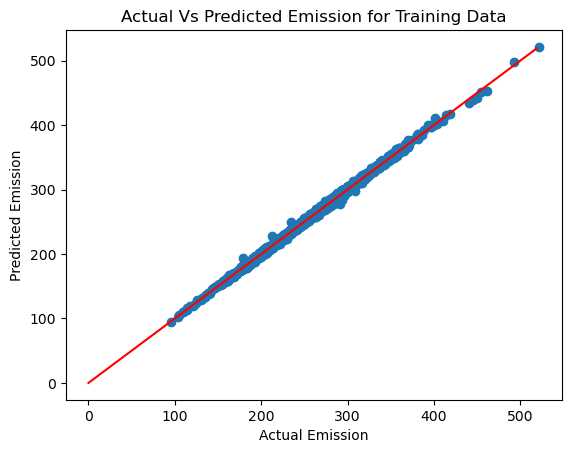

In [37]:
Predicted_Emission = pol_multi.predict(poly_multi.fit_transform(X_test))
Actual_Emission = Y_test

plt.scatter(Actual_Emission,Predicted_Emission)
plt.plot(range(520),range(520) , color = 'red')
plt.xlabel('Actual Emission')
plt.ylabel('Predicted Emission')
plt.title('Actual Vs Predicted Emission for Training Data')
plt.show()

In [38]:
poly_bi_train_score = pol_bi.score(poly_bi.fit_transform(X_bivarianttrain), Y_bivarianttrain)
poly_bi_test_score = pol_bi.score(poly_bi.fit_transform(X_bivarianttest), Y_bivarianttest)
poly_multi_train_score = pol_multi.score(poly_multi.fit_transform(X_train), Y_train)
poly_multi_test_score = pol_multi.score(poly_multi.fit_transform(X_test), Y_test)

print('\t\t\tPolynomial Regression ')
print('Score \t\t Training Data \t\t Testing Data')
print('Bivariant \t' , poly_bi_train_score , '\t' , poly_bi_test_score)
print('Multivariant \t' , poly_multi_train_score , '\t' , poly_multi_test_score)

			Polynomial Regression 
Score 		 Training Data 		 Testing Data
Bivariant 	 0.8756755721095554 	 0.8836144484185791
Multivariant 	 0.9978722754146947 	 0.9978978633126901


<font size="5">**Comparison between Models**</font>

In [41]:
print('\t\t\tLinear Regression ')
print('Score \t\t Training Data \t\t Testing Data')
print('Bivariant \t' , linear_bi_train_score , '\t' , linear_bi_test_score)
print('Multivariant \t' , linear_multi_train_score  , '\t' , linear_multi_test_score)

print('\n')

print('\t\t\tPolynomial Regression ')
print('Score \t\t Training Data \t\t Testing Data')
print('Bivariant \t' , poly_bi_train_score , '\t' , poly_bi_test_score)
print('Multivariant \t' , poly_multi_train_score , '\t' , poly_multi_test_score)

			Linear Regression 
Score 		 Training Data 		 Testing Data
Bivariant 	 0.8427749648867768 	 0.8570067872140167
Multivariant 	 0.9924741962440671 	 0.994151037968295


			Polynomial Regression 
Score 		 Training Data 		 Testing Data
Bivariant 	 0.8756755721095554 	 0.8836144484185791
Multivariant 	 0.9978722754146947 	 0.9978978633126901
